In [ ]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt 
import streamlit as st 
import joblib
import seaborn as sns 
import statistics as sts 
from scipy.spatial import distance,distance_matrix
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [ ]:
np.random.seed(42)
temparature=np.random.randint(low=0,high=50,size=10000)
cost_icecream=np.random.randint(low=10,high=1000,size=10000)
ice_cream_status=['Completed','nostock','Not Completed']
status=np.random.choice(ice_cream_status,size=10000)
ice_creams_names=['vennala','chocolate','pista','grapes']
names=np.random.choice(ice_creams_names,size=10000)
dict_ice={
    "temp":temparature,
    "cost_ice":cost_icecream,
    "status_ice":status,
    "name":names
    
}

In [ ]:
df=pd.DataFrame(data=dict_ice,columns=['temp','cost_ice','status_ice','name'])
df.head(10).columns

In [ ]:
df.describe()
df.info()

In [113]:
df.columns

Index(['temp', 'cost_ice', 'status_ice', 'name'], dtype='object')

In [117]:
df['name'].unique()

array(['vennala', 'pista', 'grapes', 'chocolate'], dtype=object)

In [121]:
mapping_data1={
    "vennala":1,
    "pista":2,
    "grapes":3,
    "chocolate":4
}

df["name_encoded"]=df['name'].map(mapping_data1)
df



df1=pd.DataFrame(data=df,columns=['temp','cost_ice','status_encoded','name_encoded'])
df1

,temp,cost_ice,status_encoded,name_encoded
0,38,705,1,1
1,28,642,1,2
2,14,853,1,3
3,42,510,2,3
4,7,613,3,3
...,...,...,...,...
9995,25,72,1,3
9996,21,518,3,4
9997,30,301,1,4
9998,42,100,1,2


In [116]:
mapping_data={
    "Completed":1,
    "nostock":2,
    "Not Completed":3
}
df['status_encoded']=df['status_ice'].map(mapping_data)
df

,temp,cost_ice,status_ice,name,status_encoded
0,38,705,Completed,vennala,1
1,28,642,Completed,pista,1
2,14,853,Completed,grapes,1
3,42,510,nostock,grapes,2
4,7,613,Not Completed,grapes,3
...,...,...,...,...,...
9995,25,72,Completed,grapes,1
9996,21,518,Not Completed,chocolate,3
9997,30,301,Completed,chocolate,1
9998,42,100,Completed,pista,1


In [123]:
df1.corr(method='spearman').round(2)

,temp,cost_ice,status_encoded,name_encoded
temp,1.00,0.00,-0.02,-0.01
cost_ice,0.00,1.00,0.01,-0.01
status_encoded,-0.02,0.01,1.00,0.01
name_encoded,-0.01,-0.01,0.01,1.00


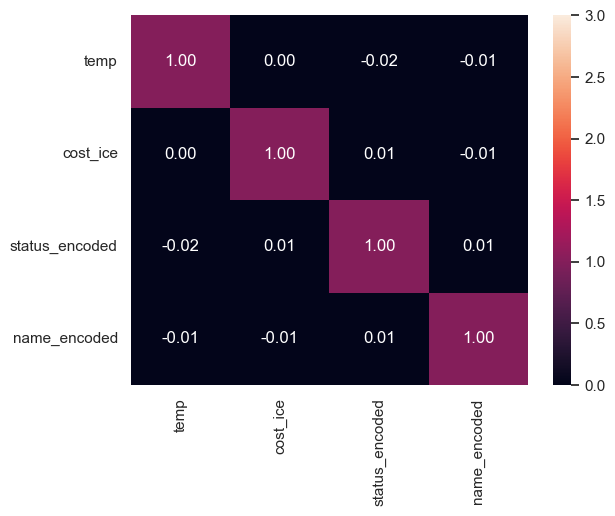

In [180]:
correction=df1.corr(method='pearson').round(2)

col1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=col1)
sns.heatmap(data=correction,annot=True,cbar=True,fmt='.2f',vmin=0,vmax=3)
plt.show()

In [176]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   temp            10000 non-null  int32
 1   cost_ice        10000 non-null  int32
 2   status_encoded  10000 non-null  int64
 3   name_encoded    10000 non-null  int64
dtypes: int32(2), int64(2)
memory usage: 234.5 KB


In [196]:
x=df1[['temp','status_encoded','name_encoded']]
y=df1['cost_ice'].values.reshape(-1,1)

In [259]:
from sklearn.pipeline import Pipeline


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

linear_reg=LinearRegression()



polyno1=PolynomialFeatures(degree=4,include_bias=True)


model1=Pipeline(steps=[
    ("poly1",polyno1),
    ("linear",linear_reg)
    
])

model2=Pipeline(steps=[
    ("linear1",linear_reg)
    
])

model_dict={
    "linear_regression":model2,
    "polynomil":model1
}


for name,model in model_dict.items():
    print(name)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(f"\n{y_pred.tolist()}\n")
    print(model.score(x_test,y_pred))
    meanabserror=mean_absolute_error(y_test,y_pred)
    print(meanabserror)
    mean_sqerr=mean_squared_error(y_test,y_pred)
    print(mean_sqerr)
    r2score=r2_score(y_test,y_pred)
    print(r2score)

print(linear_reg.intercept_[0])
print(linear_reg.coef_[0])

linear_regression

[[510.13253355334035], [504.7703938193147], [507.49112169546913], [507.06215051674707], [508.16837085632164], [502.5342664763026], [502.73864633675703], [506.70076412356394], [500.1648192644247], [507.83892715369603], [504.21635879842137], [500.84206842527726], [503.8786590691011], [498.82042667162625], [500.1073402077924], [509.42149199971834], [503.8211800124688], [510.3470191427014], [496.890056367377], [505.93224351330963], [499.6546823652075], [511.8146258754591], [512.0291114648202], [501.3367746873262], [501.73380317549083], [499.0687046537567], [507.86261381755884], [500.69331791924316], [505.9998282988485], [503.1101384588468], [501.40435947286517], [501.213560547367], [508.1007860707827], [497.0470629001057], [505.10809354863494], [501.1797681545975], [508.05341274305704], [498.5484620256329], [506.847664927386], [508.99252082099633], [499.8928546184314], [510.4465466187978], [502.19471704477036], [511.63393267886755], [500.5701037792839], [497.533513135460

In [ ]:
cross_score=cross_val_score(linear_reg,x,y,scoring='neg_mean_squared_error',cv=10,n_jobs=-1)
result=np.mean(cross_score)
print(abs(result))
print(abs(cross_score))

from sklearn.model_selection import GridSearchCV
params_grid={ 'max_depth':[2,4,6,8,10],'min_samples_split':[10,20,30,50,100,200,150]}
clf=GridSearchCV(linear_reg,param_grid=,n_jobs=-1,cv=10,scoring='accuracy')
clf.fit(x_train,y_train)



81665.8011975841
[81098.85287436 81388.6323967  79526.82608622 78390.76121315
 81082.97293714 81979.33250228 84594.3903999  82531.48990903
 80900.21802137 85164.5356357 ]


TypeError: GridSearchCV.__init__() missing 1 required positional argument: 'param_grid'

In [203]:
Scalling_data=StandardScaler()
scalling_x_data=Scalling_data.fit_transform(x).round(4)

scalling_y_data=Scalling_data.fit_transform(y).round(4)
scalling_x_data =abs(scalling_x_data)
scalling_x_data

array([[0.9328, 1.2273, 1.3189],
       [0.2356, 1.2273, 0.422 ],
       [0.7405, 1.2273, 0.4749],
       ...,
       [0.3751, 1.2273, 1.3718],
       [1.2117, 1.2273, 0.422 ],
       [1.0891, 0.002 , 0.422 ]], shape=(10000, 3))

In [204]:
scalling_org=Scalling_data.inverse_transform(scalling_x_data)
scalling_org

array([[772.77477176, 856.90868973, 883.0773379 ],
       [573.59593438, 856.90868973, 626.8474193 ],
       [717.83775164, 856.90868973, 641.9600993 ],
       ...,
       [613.44884289, 856.90868973, 898.1900179 ],
       [852.45202039, 856.90868973, 626.8474193 ],
       [817.42717033, 506.86016786, 626.8474193 ]], shape=(10000, 3))

In [ ]:
class Anomolies_detection_robust:
    def __init__(self,data):
        self.data=data
    def function_check(self):
        q1=self.data.quantile(0.25)
        q3=self.data.quantile(0.75)
        iqr=q3-q1 
        lower_bound=q1-1.5*iqr 
        high_bound=q3+1.5*iqr
        anomolies=self.data[(self.data<lower_bound) | (self.data > high_bound)]
        return anomolies


data={
    "cool1":[0.4,0,1,2,3,4,5,90,0.02,290,12,900],
    "cool2":[90,121,123,1234,908,786,9876,678,908,8765,1234590,90]
}
df1=pd.DataFrame(data=data)  
all_numerics=df1.select_dtypes(include=['number'])
df_cleaned=df1.copy()


for col in all_numerics.columns:
    detect=Anomolies_detection_robust(df1[col])
    results=detect.function_check()
    if not results.empty:
        print(f"{col} and {results.index} and {results.to_list()}")
        
    else:
        print(f"{col} no anomolies")
    df_cleaned=df_cleaned.drop()
    df_cleaned